# Telecom Churn Prediction - Exploratory Data Analysis

This notebook performs exploratory data analysis on the telecom churn dataset used in the project.

## Objectives
- Load and inspect the dataset
- Understand feature types and target distribution
- Check missing values
- Analyze churn imbalance
- Explore relationships between key features and churn

## Notes
This notebook is for analysis only. Production logic is implemented in the `src/` package.

In [1]:
from __future__ import annotations
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import os

# Move ONE level up from notebooks → project root
PROJECT_ROOT = Path.cwd().resolve().parent

# Set environment variable so your settings.py uses correct root
os.environ["PROJECT_ROOT"] = str(PROJECT_ROOT)

# Add src to Python path
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

# print("PROJECT_ROOT:", PROJECT_ROOT)

In [2]:
from telecom_churn_prediction.settings import settings

print(settings.raw_dataset_path)
print(settings.raw_dataset_path.exists())

C:\Users\Dileep Samaji\Desktop\AI\telecom-churn-prediction\data\raw\telco_customer_churn.csv
True


In [3]:
from telecom_churn_prediction.data.data_loader import load_raw_dataset, clean_dataset

## Load Dataset
We first load the raw dataset and apply the same initial cleaning used in the project.

In [4]:
raw_df = load_raw_dataset()
df = clean_dataset(raw_df)

print("Raw shape:", raw_df.shape)
print("Cleaned shape:", df.shape)
df.head()

2026-04-01 11:51:58,349 | INFO | telecom_churn_prediction.data.data_loader | Loading dataset from C:\Users\Dileep Samaji\Desktop\AI\telecom-churn-prediction\data\raw\telco_customer_churn.csv


Raw shape: (7043, 21)
Cleaned shape: (7032, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Dataset Overview
We inspect column names, data types, and basic statistics.

In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

In [6]:
df.describe(include="all").T.head(25)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7032,7032,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7032,2,Male,3549,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7032.0,NaN,NaN,NaN,0.1624,0.368844,0.0,0.0,0.0,0.0,1.0
Partner,7032,2,No,3639,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7032,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7032.0,NaN,NaN,NaN,32.421786,24.54526,1.0,9.0,29.0,55.0,72.0
PhoneService,7032,2,Yes,6352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7032,3,No,3385,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7032,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7032,3,No,3497,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Missing Values
Check whether there are missing or invalid values remaining after cleaning.

In [7]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

Series([], dtype: int64)

## Target Distribution
The target column is `Churn`. We inspect class balance because churn prediction is typically an imbalanced classification problem.

In [8]:
target_counts = df["Churn"].value_counts()
target_counts

Churn
No     5163
Yes    1869
Name: count, dtype: int64

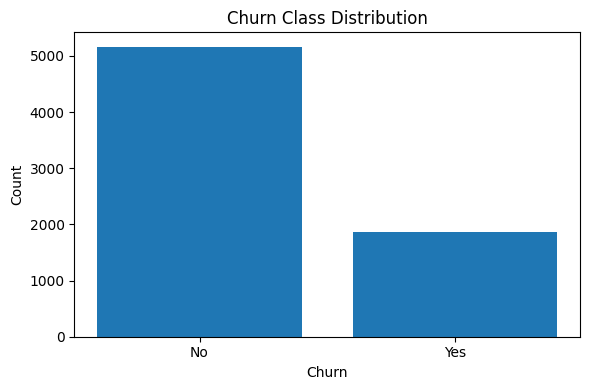

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(target_counts.index, target_counts.values)
ax.set_title("Churn Class Distribution")
ax.set_xlabel("Churn")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

### Observation
The dataset is imbalanced, with more `No Churn` customers than `Churn` customers.  
This is important because accuracy alone may be misleading, so metrics such as recall, F1-score, ROC-AUC, and threshold tuning are necessary.

## Churn by Contract Type
Contract type is often strongly associated with churn risk.

In [10]:
import pandas as pd

In [11]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index")
contract_churn

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887228,0.112772
Two year,0.971513,0.028487


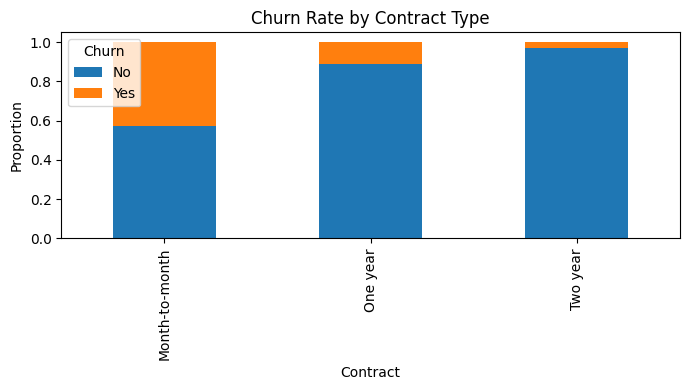

In [12]:
contract_churn.plot(kind="bar", stacked=True, figsize=(7, 4))
plt.title("Churn Rate by Contract Type")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

### Observation
Month-to-month customers tend to have higher churn risk than one-year or two-year contract customers.  
This aligns with business intuition: short commitment often corresponds to higher customer instability.

## Tenure vs Churn
Tenure is another key variable for customer stability.

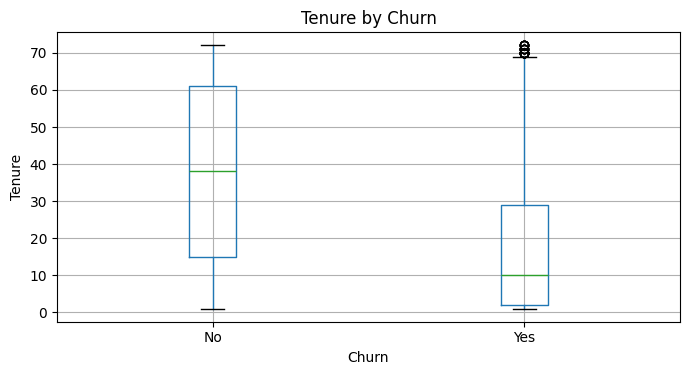

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
df.boxplot(column="tenure", by="Churn", ax=ax)
plt.title("Tenure by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.tight_layout()
plt.show()

Customers who churn generally have lower tenure, indicating that newer customers are more likely to leave.

### Observation
Customers who churn generally have lower tenure, indicating that newer customers are more likely to leave.

fig, ax = plt.subplots(figsize=(7, 4))
df.boxplot(column="MonthlyCharges", by="Churn", ax=ax)
plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.show()

Higher monthly charges often appear associated with churn, especially when combined with month-to-month contracts and weaker support/service features.

## Summary of EDA Findings

Key observations:
- The dataset is class imbalanced.
- Month-to-month contracts are associated with higher churn.
- Lower tenure customers are more likely to churn.
- Higher monthly charges may increase churn risk.
- These observations support the use of threshold-aware, business-oriented churn modeling.